In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("tren-ligero-cdmx.csv")

In [3]:
df

,fecha,mes,anio,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Prepago,14251.000000
1,2022-01-01,Enero,2022,Gratuidad,1806.000000
2,2022-01-02,Enero,2022,Prepago,21875.000000
3,2022-01-02,Enero,2022,Gratuidad,2259.000000
4,2022-01-03,Enero,2022,Prepago,49290.000000
...,...,...,...,...,...
3219,2026-05-29,Mayo,2026,Gratuidad,17434.878050
3220,2026-05-30,Mayo,2026,Prepago,58193.000000
3221,2026-05-30,Mayo,2026,Gratuidad,8762.461208
3222,2026-05-31,Mayo,2026,Prepago,34591.000000


In [4]:
# ¿Hay datos nulos?
df.isna().sum() # No hay datos nulos

fecha        0
mes          0
anio         0
tipo_pago    0
afluencia    0
dtype: int64

In [5]:
# Dimensiones del Data Frame
print(f"El Data Frame tiene {df.shape[0]} filas")
print(f"El Data Frame tiene {df.shape[1]} columnas")

El Data Frame tiene 3224 filas
El Data Frame tiene 5 columnas


In [6]:
# Exploramos el tipo de dato de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3224 entries, 0 to 3223
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      3224 non-null   str    
 1   mes        3224 non-null   str    
 2   anio       3224 non-null   int64  
 3   tipo_pago  3224 non-null   str    
 4   afluencia  3224 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 126.1 KB


In [7]:
# Cantidad de datos que tiene cada año
df["anio"].value_counts()

anio
2024    732
2022    730
2023    730
2025    730
2026    302
Name: count, dtype: int64

## ⚠️ Observación de la cantidad de datos que tiene cada año

Como se puede observar al ejecutar la celda de
   ```py
   df["anio"].value_counts()
   ```
Todos los años (2022, 2023, 2024...) cuentan con casi la misma cantidad de datos, excepto el año 2026 ya que aún no acaba el año. Lo que nos facilitará el análisis ya que no tendremos datos de más o datos faltantes y teniendo en cuenta que los años del 2022 al 2025 cuentan con casi la misma cantidad de datos podemos hacer una **regresión lineal** para predecir la afluencia del 2026.

## ¿Cuál es la afluencia total por cada año?

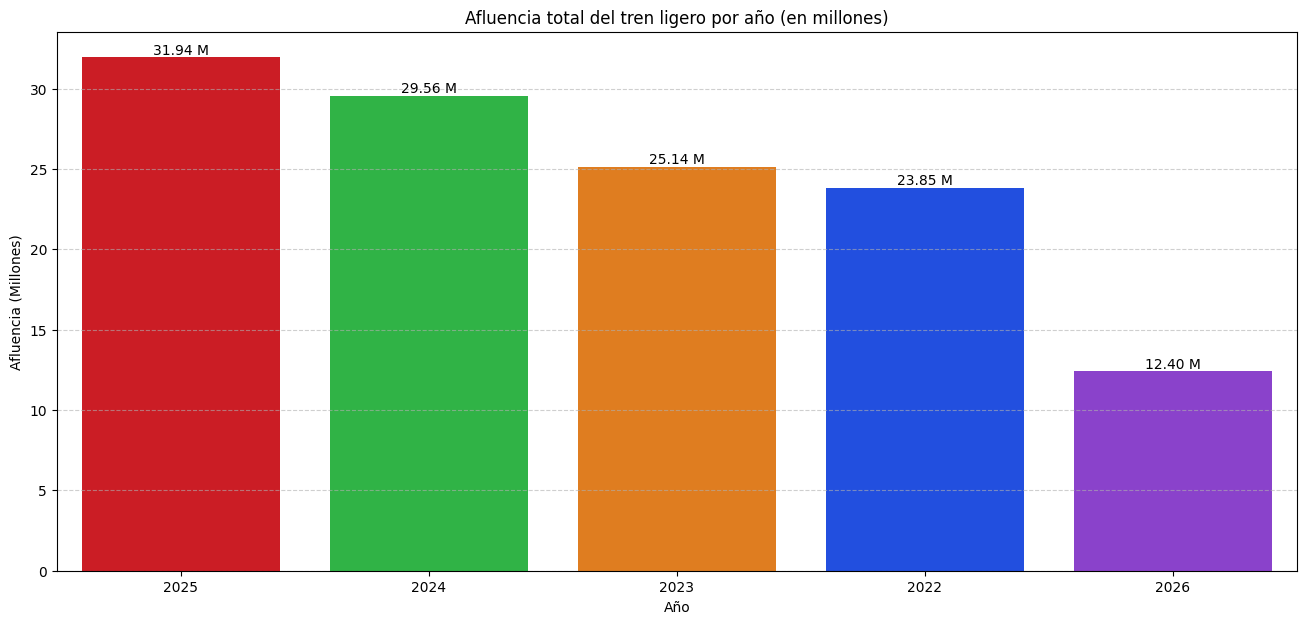

In [8]:
# Agrupamos y ordenamos de mayor a menor
afluencia_por_año = df.groupby("anio")["afluencia"].sum().sort_values(ascending=False)

# Dividimos entre 1,000,000 para simplificar la escala
afluencia_millones = afluencia_por_año / 1_000_000

# 2. Graficamos
plt.figure(figsize=(16, 7))
plt.title("Afluencia total del tren ligero por año (en millones)")

# usamos order=afluencia_millones.index
barras = sns.barplot(x=afluencia_millones.index,
                     y=afluencia_millones.values,
                     hue=afluencia_millones.index,
                     order=afluencia_millones.index,  # <-- Esto frena el reordenamiento automático
                     palette="bright",
                     legend=False)                     # Quita la leyenda repetitiva de los años

for contenedores in barras.containers:
    barras.bar_label(contenedores, fmt='%.2f M')   

plt.ylabel("Afluencia (Millones)")
plt.xlabel("Año")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿Qué tanto ha crecido la afluencia del tren ligero cada año?

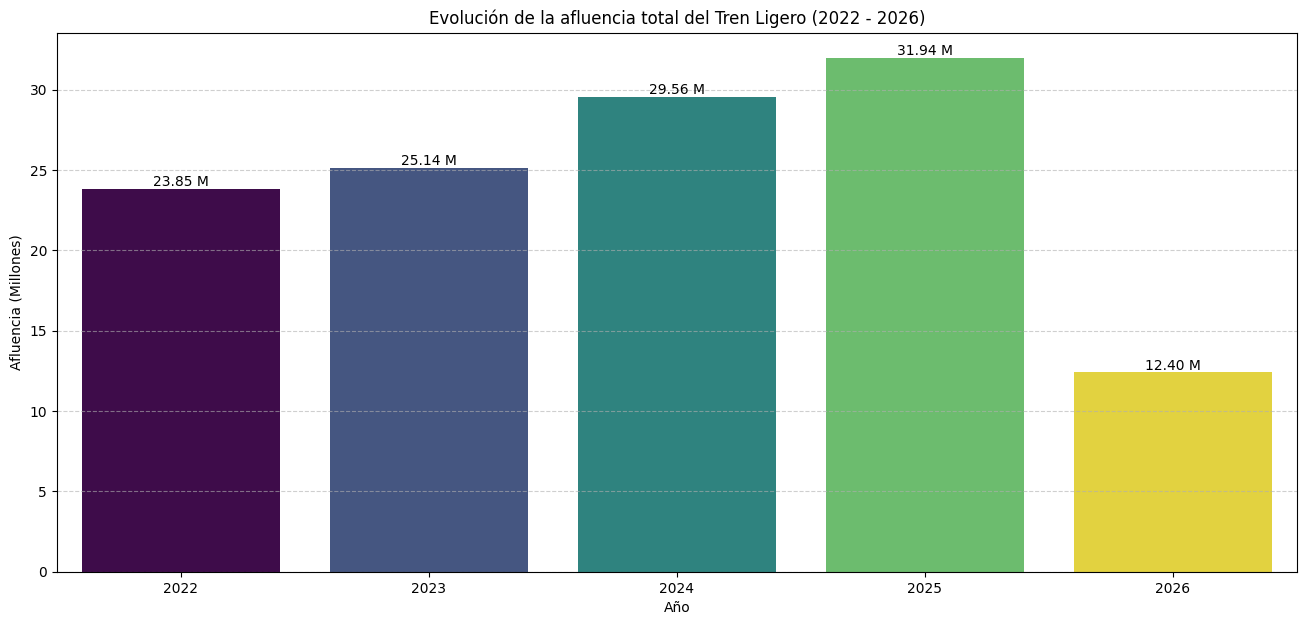

In [9]:
# Agrupamos la afluencia anual pero de manera cronológica
afluencia_cronologica = df.groupby("anio")["afluencia"].sum() / 1_000_000

# Graficamos
plt.figure(figsize=(16,7))
plt.title("Evolución de la afluencia total del Tren Ligero (2022 - 2026)")
barras = sns.barplot(x=afluencia_cronologica.index,
                     y=afluencia_cronologica.values,
                     hue=afluencia_cronologica.index,
                     palette="viridis",
                     legend=False)
for contenedores in barras.containers:
    barras.bar_label(contenedores, fmt='%.2f M')   

plt.ylabel("Afluencia (Millones)")
plt.xlabel("Año")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿En qué meses sube mas la afluencia? Sumando todos los años sin el 2026

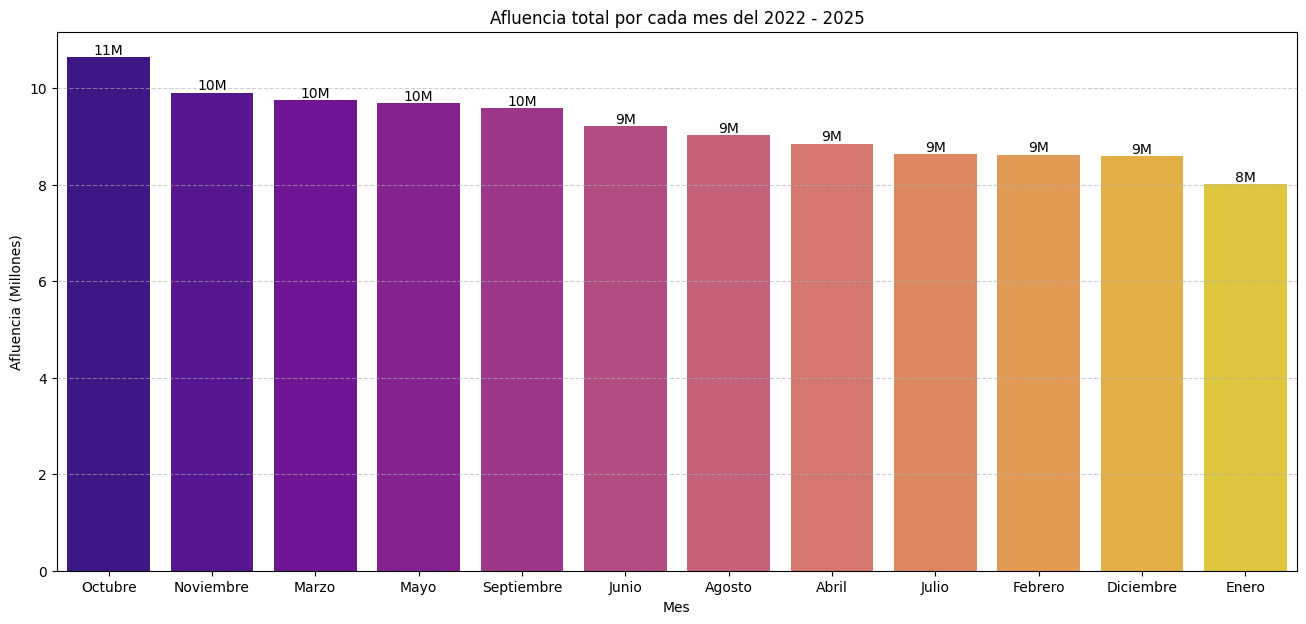

In [10]:
# Creamos un Data Frame sin el año 2026 para no alterar el resultado
df_sin_2026 = df[df["anio"] != 2026]

# Agrupamos afluencia por cada mes del año
afluencia_mes = df_sin_2026.groupby("mes")["afluencia"].sum().sort_values(ascending=False)

# Dividimos entre 1,000,000 para simplificar la escala
afluencia_mes_simpli = afluencia_mes / 1_000_000

# Graficamos
plt.figure(figsize=(16,7))
plt.title("Afluencia total por cada mes del 2022 - 2025")

barras = sns.barplot(x=afluencia_mes_simpli.index,
                     y=afluencia_mes_simpli.values,
                     hue=afluencia_mes_simpli.index,
                     palette="plasma")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0fM')
plt.xlabel("Mes")
plt.ylabel("Afluencia (Millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿Qué tipo de pago genera mas afluencia?

In [11]:
df["tipo_pago"].value_counts()

tipo_pago
Prepago      1612
Gratuidad    1612
Name: count, dtype: int64

In [12]:
# Renombramos "Prepago" por "Targeta de Movilidad" para mas comodidad
targeta_movilidad = {
    "Prepago": "Targeta de Movilidad"
}
df_sin_2026["tipo_pago"] = df_sin_2026["tipo_pago"].replace(targeta_movilidad, regex=True)

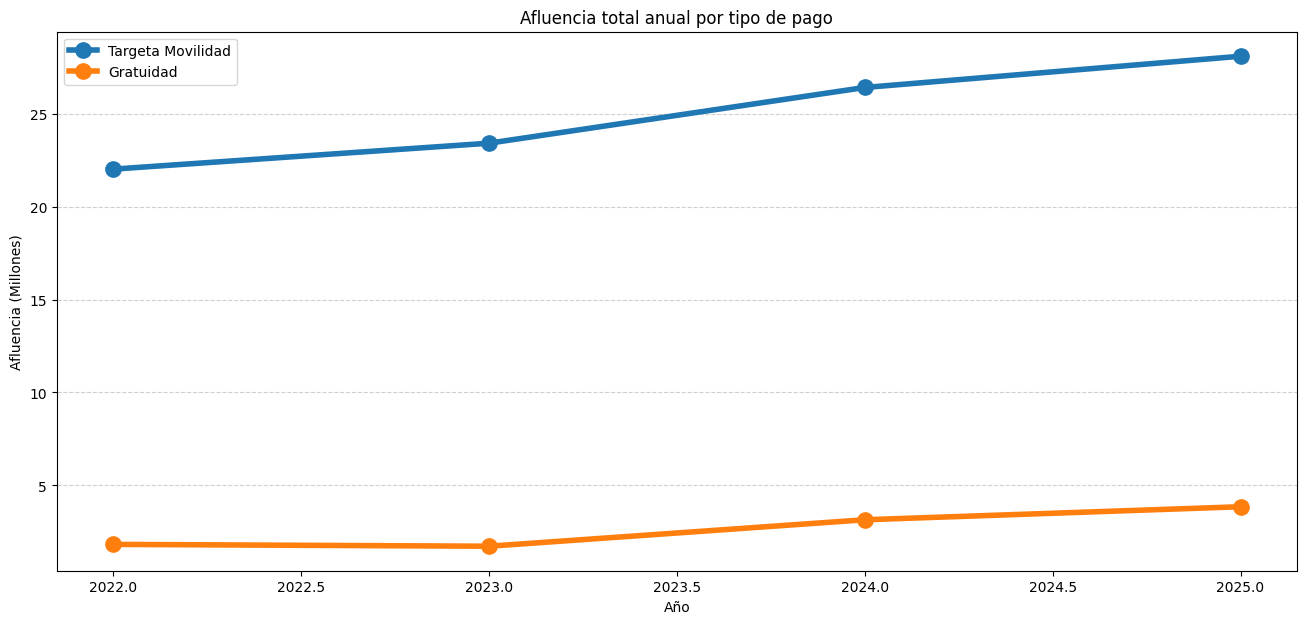

In [13]:
# Filtramos por Targeta de Movilidad
targeta_mov = df_sin_2026[df_sin_2026["tipo_pago"] == "Targeta de Movilidad"] # Tiene 1461 filas

# Filtramor por Gratuidad
gratuidad = df_sin_2026[df_sin_2026["tipo_pago"] == "Gratuidad"] # Tiene 1461 filas

# Agrupamos afluencia por cada tipo de pago
afl_targeta_mov = targeta_mov.groupby("anio")["afluencia"].sum() / 1_000_000

afl_gratuidad = gratuidad.groupby("anio")["afluencia"].sum() / 1_000_000

# Graficamos Targeta de Movilidad
plt.figure(figsize=(16,7))
plt.title("Afluencia total anual por tipo de pago")
plt.plot(afl_targeta_mov.index,
         afl_targeta_mov.values,
         marker="o",
         linewidth=4,
         markersize=11,
         label="Targeta Movilidad")

# Graficamos Gratuidad
plt.plot(afl_gratuidad.index,
         afl_gratuidad.values,
         marker="o",
        linewidth=4,
         markersize=11,
         label="Gratuidad")

plt.legend()
plt.xlabel("Año")
plt.ylabel("Afluencia (Millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## Predicción de afluencia por Targeta de Movilidad para el 2026

La afluencia que habrá en el tren ligero usando la targeta de movilidad para el 2026 será de 30.29 millones de personas


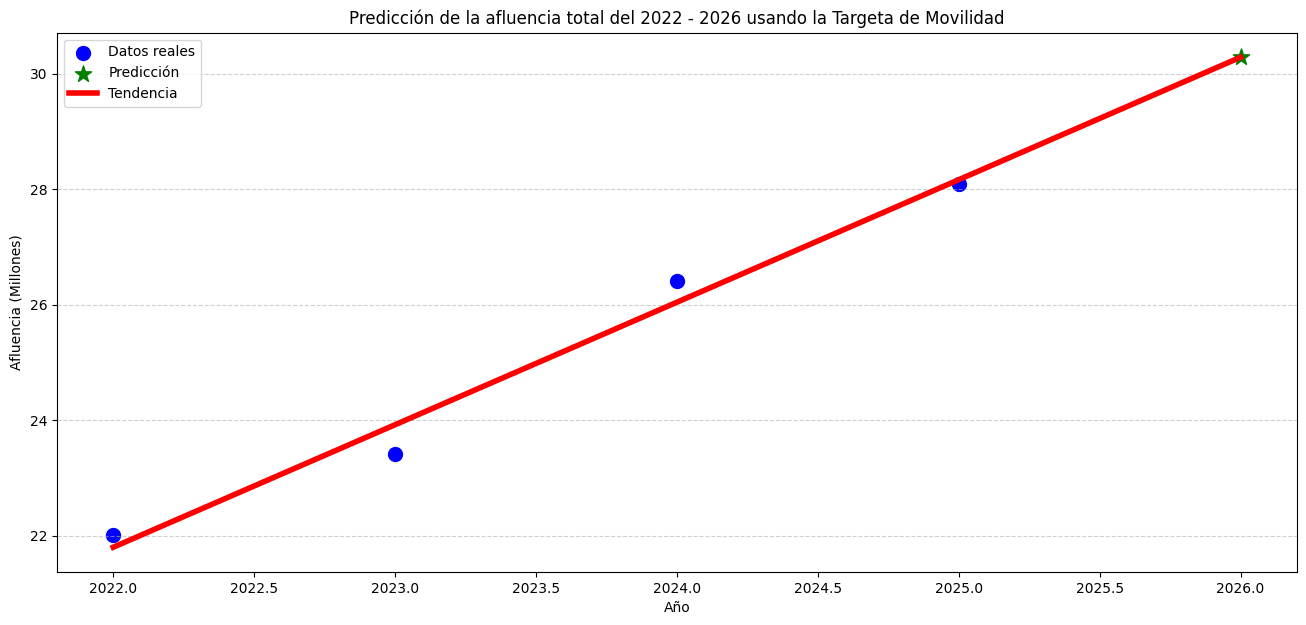

In [18]:
# Creamos las variables X, y
X = np.linspace(2022,2025,4).reshape(-1 ,1)
y = afl_targeta_mov.values

# Creamos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Creamos el array de la predicción
años_futuro = np.array([2026]).reshape(-1 ,1)

# Hacemos la predicción
predic = modelo.predict(años_futuro)

# Mostramos en pantalla
print(f"La afluencia que habrá en el tren ligero usando la targeta de movilidad para el 2026 será de {predic[0]:.2f} millones de personas")

# Graficamos
plt.figure(figsize=(16,7))
plt.title("Predicción de la afluencia total del 2022 - 2026 usando la Targeta de Movilidad")

# Puntos azules (datos reales)
plt.scatter(X,
            y,
            s=100,
            color="blue",
            label="Datos reales")

# Punto verde (predicción)
plt.scatter(años_futuro,
            predic,
            s=150,
            color="green",
            marker="*",
            label="Predicción")

# Linea (tendencia)
X_extendido = np.linspace(2022,2026,5).reshape(-1, 1)
y_extendido = modelo.predict(X_extendido)
plt.plot(X_extendido,
         y_extendido,
         linewidth=4,
         color="red",
         label="Tendencia")

plt.xlabel("Año")
plt.ylabel("Afluencia (Millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.legend()
plt.show()